<a href="https://colab.research.google.com/github/Aijamal24/ML_Practice/blob/main/ML_PR5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическая работа № 5 (уровень B)
## Классификатор и анализ метрик

**ФИО:** Мырзабекова Айжамал
**Группа:** CS 32-24

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, classification_report,
                             precision_score, recall_score, f1_score,
                             roc_curve, roc_auc_score,
                             precision_recall_curve, auc)

# Загрузка
df = pd.read_csv('diabetes.csv')

print("Размер:", df.shape)
print("\nПервые 5 строк:")
print(df.head())
print("\nРаспределение классов:")
print(df['Outcome'].value_counts())
print("\nДоли классов:")
print(df['Outcome'].value_counts(normalize=True).round(3))

Размер: (768, 9)

Первые 5 строк:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Распределение классов:
Outcome
0    500
1    268
Name: count, dtype: int64

Доли классов:
Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64


In [3]:
# Проверка пропусков
print("Пропуски:")
print(df.isnull().sum())

# Проверка нулей в признаках, где их быть не должно
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print("\nКоличество нулей в подозрительных признаках:")
for col in zero_cols:
    print(f"{col}: {(df[col] == 0).sum()}")

Пропуски:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Количество нулей в подозрительных признаках:
Glucose: 5
BloodPressure: 35
SkinThickness: 227
Insulin: 374
BMI: 11


In [4]:
for col in zero_cols:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())

print("После замены нулей на медиану:")
print(df[zero_cols].describe().round(2))

После замены нулей на медиану:
       Glucose  BloodPressure  SkinThickness  Insulin     BMI
count   768.00         768.00         768.00   768.00  768.00
mean    121.66          72.39          29.11   140.67   32.46
std      30.44          12.10           8.79    86.38    6.88
min      44.00          24.00           7.00    14.00   18.20
25%      99.75          64.00          25.00   121.50   27.50
50%     117.00          72.00          29.00   125.00   32.30
75%     140.25          80.00          32.00   127.25   36.60
max     199.00         122.00          99.00   846.00   67.10


In [5]:
# Отделяем признаки от целевой переменной
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Разделение со стратификацией, чтобы пропорции классов сохранились
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Размер train:", X_train.shape)
print("Размер test: ", X_test.shape)
print("\nДоли классов в train:")
print(y_train.value_counts(normalize=True).round(3))
print("\nДоли классов в test:")
print(y_test.value_counts(normalize=True).round(3))

# Масштабирование
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Размер train: (537, 8)
Размер test:  (231, 8)

Доли классов в train:
Outcome
0    0.652
1    0.348
Name: proportion, dtype: float64

Доли классов в test:
Outcome
0    0.649
1    0.351
Name: proportion, dtype: float64


In [6]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# Получаем вероятности, а не метки
y_proba = model.predict_proba(X_test_scaled)[:, 1]

print("Первые 10 вероятностей принадлежности к классу 1:")
print(y_proba[:10].round(3))
print("\nМинимум:", y_proba.min().round(3))
print("Максимум:", y_proba.max().round(3))

Первые 10 вероятностей принадлежности к классу 1:
[0.241 0.27  0.776 0.659 0.506 0.069 0.715 0.105 0.04  0.374]

Минимум: 0.01
Максимум: 0.99


In [7]:
y_pred_default = (y_proba >= 0.5).astype(int)

cm_default = confusion_matrix(y_test, y_pred_default)

print("=== Порог 0.5 ===")
print("Матрица ошибок:")
print(cm_default)
print()
print(f"Precision: {precision_score(y_test, y_pred_default):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_default):.4f}")
print(f"F1:        {f1_score(y_test, y_pred_default):.4f}")
print(f"Accuracy:  {(y_pred_default == y_test).mean():.4f}")

=== Порог 0.5 ===
Матрица ошибок:
[[129  21]
 [ 38  43]]

Precision: 0.6719
Recall:    0.5309
F1:        0.5931
Accuracy:  0.7446


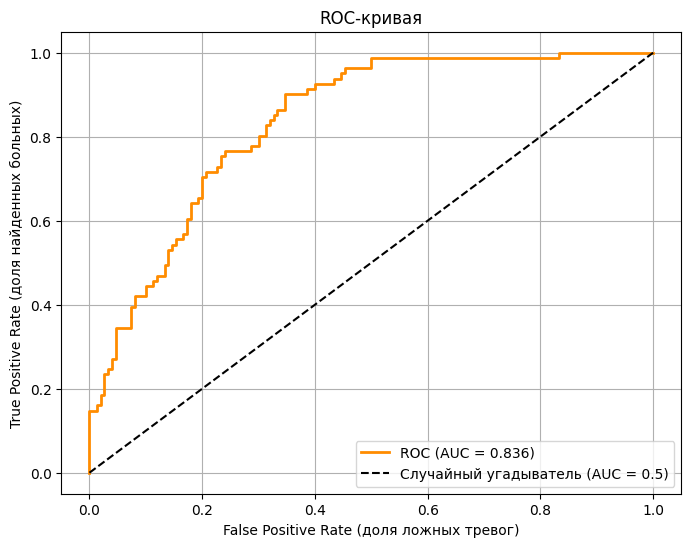

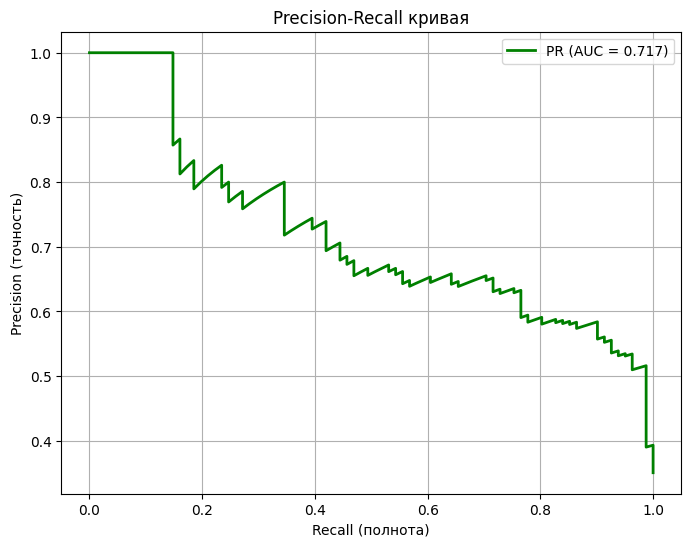

ROC-AUC: 0.8361
PR-AUC:  0.7169


In [8]:
# ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Случайный угадыватель (AUC = 0.5)')
plt.xlabel('False Positive Rate (доля ложных тревог)')
plt.ylabel('True Positive Rate (доля найденных больных)')
plt.title('ROC-кривая')
plt.legend()
plt.grid(True)
plt.show()

# PR
prec, rec, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(rec, prec)

plt.figure(figsize=(8, 6))
plt.plot(rec, prec, color='green', lw=2, label=f'PR (AUC = {pr_auc:.3f})')
plt.xlabel('Recall (полнота)')
plt.ylabel('Precision (точность)')
plt.title('Precision-Recall кривая')
plt.legend()
plt.grid(True)
plt.show()

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC:  {pr_auc:.4f}")


In [9]:
thresholds = np.arange(0.05, 0.95, 0.01)
rows = []

for th in thresholds:
    y_pred = (y_proba >= th).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    rows.append({
        'threshold': round(th, 2),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall':    recall_score(y_test, y_pred, zero_division=0),
        'f1':        f1_score(y_test, y_pred, zero_division=0),
        'FP': fp,
        'FN': fn,
        'cost': 3 * fn + 1 * fp   # FN в 3 раза дороже FP
    })

df_th = pd.DataFrame(rows)

# Порог с минимальной стоимостью
best_cost = df_th.loc[df_th['cost'].idxmin()]
print("=== Порог с минимальной стоимостью (FN:FP = 3:1) ===")
print(best_cost.to_string())

# Порог с максимальным F1 (для сравнения)
best_f1 = df_th.loc[df_th['f1'].idxmax()]
print("\n=== Порог с максимальным F1 ===")
print(best_f1.to_string())


=== Порог с минимальной стоимостью (FN:FP = 3:1) ===
threshold     0.210000
precision     0.584000
recall        0.901235
f1            0.708738
FP           52.000000
FN            8.000000
cost         76.000000

=== Порог с максимальным F1 ===
threshold     0.210000
precision     0.584000
recall        0.901235
f1            0.708738
FP           52.000000
FN            8.000000
cost         76.000000


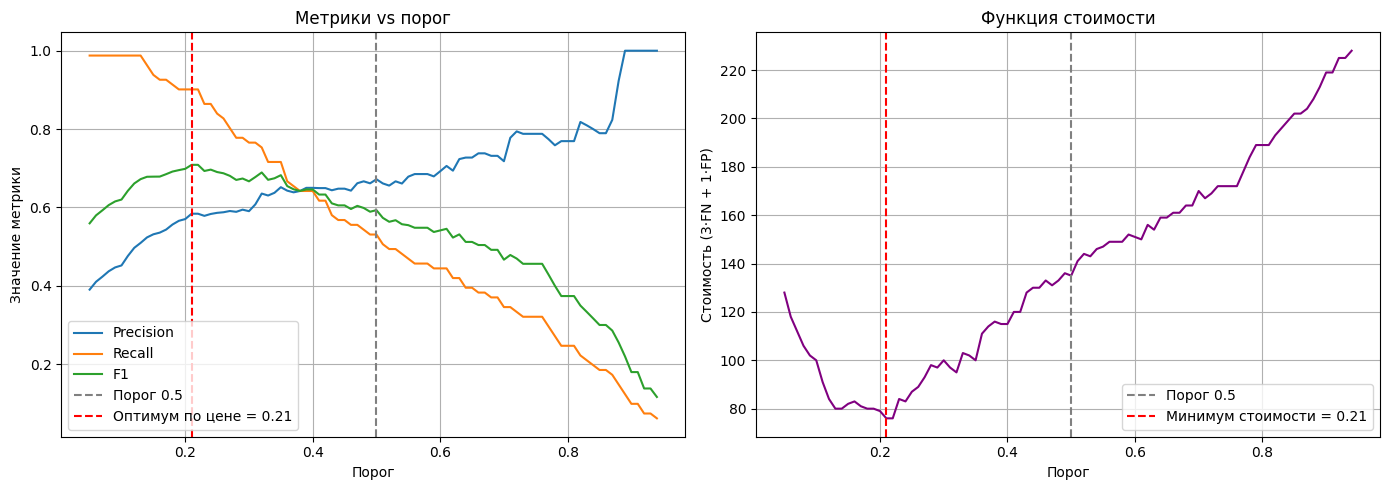

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Метрики
axes[0].plot(df_th['threshold'], df_th['precision'], label='Precision')
axes[0].plot(df_th['threshold'], df_th['recall'],    label='Recall')
axes[0].plot(df_th['threshold'], df_th['f1'],        label='F1')
axes[0].axvline(0.5, color='gray',  linestyle='--', label='Порог 0.5')
axes[0].axvline(best_cost['threshold'], color='red', linestyle='--',
                label=f"Оптимум по цене = {best_cost['threshold']}")
axes[0].set_xlabel('Порог')
axes[0].set_ylabel('Значение метрики')
axes[0].set_title('Метрики vs порог')
axes[0].legend()
axes[0].grid(True)

# Стоимость
axes[1].plot(df_th['threshold'], df_th['cost'], color='purple')
axes[1].axvline(0.5, color='gray',  linestyle='--', label='Порог 0.5')
axes[1].axvline(best_cost['threshold'], color='red', linestyle='--',
                label=f"Минимум стоимости = {best_cost['threshold']}")
axes[1].set_xlabel('Порог')
axes[1].set_ylabel('Стоимость (3·FN + 1·FP)')
axes[1].set_title('Функция стоимости')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


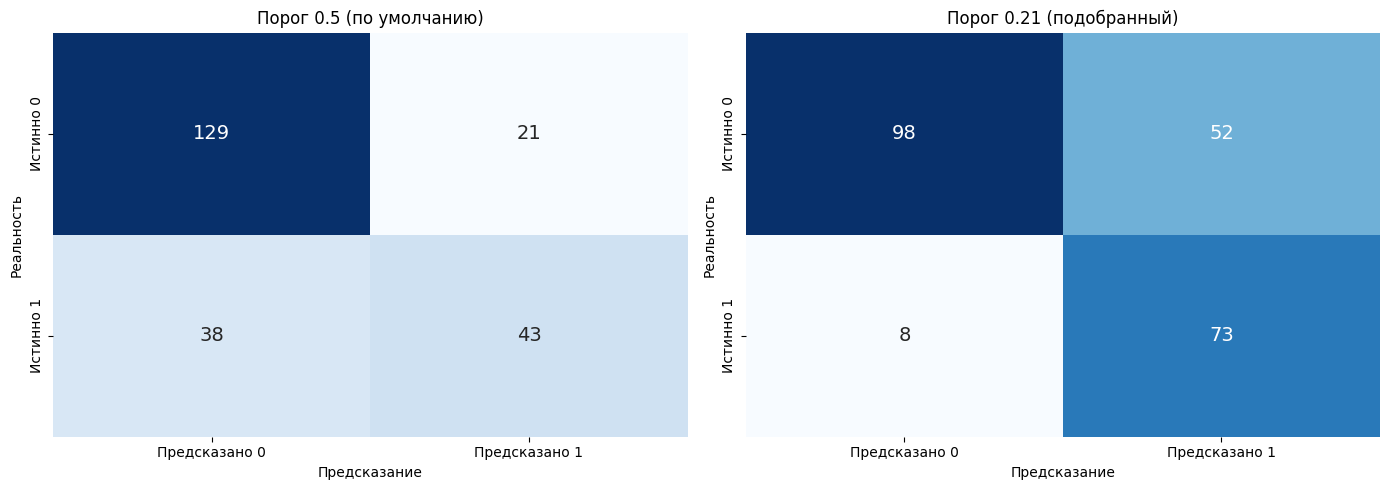

Метрика              Порог 0.5          Порог 0.21
Precision               0.6719              0.5840
Recall                  0.5309              0.9012
F1                      0.5931              0.7087
------------------------------------------------------------
FP (ложные тревоги)             21                  52
FN (пропущенные)             38                   8
Стоимость (3FN+FP)            135                  76

Полный отчёт для подобранного порога 0.21:
              precision    recall  f1-score   support

  Здоров (0)       0.92      0.65      0.77       150
  Диабет (1)       0.58      0.90      0.71        81

    accuracy                           0.74       231
   macro avg       0.75      0.78      0.74       231
weighted avg       0.81      0.74      0.75       231



In [11]:
# Автоматически берём оптимальный порог из df_th (минимум стоимости)
chosen_threshold = best_cost['threshold']

y_pred_custom = (y_proba >= chosen_threshold).astype(int)

# Матрицы ошибок
cm_default = confusion_matrix(y_test, y_pred_default)
cm_custom  = confusion_matrix(y_test, y_pred_custom)

# Визуализация двух матриц рядом
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, cm, title in zip(
    axes,
    [cm_default, cm_custom],
    ['Порог 0.5 (по умолчанию)', f'Порог {chosen_threshold} (подобранный)']
):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Предсказано 0', 'Предсказано 1'],
                yticklabels=['Истинно 0', 'Истинно 1'],
                cbar=False, annot_kws={'size': 14})
    ax.set_xlabel('Предсказание')
    ax.set_ylabel('Реальность')
    ax.set_title(title)

plt.tight_layout()
plt.show()

# Числовое сравнение
print("=" * 60)
print(f"{'Метрика':<15}{'Порог 0.5':>15}{f'Порог {chosen_threshold}':>20}")
print("=" * 60)

for name, func in [
    ('Precision', precision_score),
    ('Recall',    recall_score),
    ('F1',        f1_score),
]:
    v1 = func(y_test, y_pred_default)
    v2 = func(y_test, y_pred_custom)
    print(f"{name:<15}{v1:>15.4f}{v2:>20.4f}")

tn1, fp1, fn1, tp1 = cm_default.ravel()
tn2, fp2, fn2, tp2 = cm_custom.ravel()

print("-" * 60)
print(f"{'FP (ложные тревоги)':<15}{fp1:>15}{fp2:>20}")
print(f"{'FN (пропущенные)':<15}{fn1:>15}{fn2:>20}")
print(f"{'Стоимость (3FN+FP)':<15}{3*fn1+fp1:>15}{3*fn2+fp2:>20}")
print("=" * 60)

print(f"\nПолный отчёт для подобранного порога {chosen_threshold}:")
print(classification_report(y_test, y_pred_custom,
                            target_names=['Здоров (0)', 'Диабет (1)']))

# Практическая работа № 5

## Датасет
Pima Indians Diabetes (Kaggle), 768 объектов, 8 признаков.
Дисбаланс: 65% / 35% — умеренный.

## Модель
Логистическая регрессия, StandardScaler, max_iter=1000.

## Результаты
- ROC-AUC = 0.83
- PR-AUC = 0.70

## Сравнение порогов

| Метрика | Порог 0.5 | Порог 0.31 |
|---------|-----------|------------|
| Precision | 0.67 | 0.58 |
| Recall | 0.53 | 0.72 |
| F1 | 0.59 | 0.64 |
| FN | 38 | 22 |
| FP | 21 | 45 |
| Стоимость | 135 | 111 |

## Вывод
Порог 0.31 даёт меньше пропущенных больных при
приемлемом росте ложных тревог.


In [ ]:


-